In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/poll_data.csv")

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,Age Group,Preferred Tool,Satisfaction
0,25-34,Python,4
1,25-34,Python,2
2,18-24,Excel,2
3,25-34,Excel,2
4,25-34,Python,2


In [4]:
# shape
print("Shape:", df.shape)

# info
df.info()

# statistics
df.describe()

Shape: (50, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age Group       50 non-null     object
 1   Preferred Tool  50 non-null     object
 2   Satisfaction    50 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


,Satisfaction
count,50.000000
mean,3.060000
std,1.391079
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [5]:
df.isnull().sum()


Age Group         0
Preferred Tool    0
Satisfaction      0
dtype: int64

In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Drop missing values
df = df.dropna()

# Standardize text
df["Preferred Tool"] = df["Preferred Tool"].str.strip().str.title()

# Convert to numeric
df["Satisfaction"] = pd.to_numeric(df["Satisfaction"], errors='coerce')

df.head()

,Age Group,Preferred Tool,Satisfaction
0,25-34,Python,4
1,25-34,Python,2
2,18-24,Excel,2
3,25-34,Excel,2
5,25-34,Python,1


In [7]:
tool_counts = df["Preferred Tool"].value_counts()
tool_counts

Preferred Tool
Python    10
Excel      9
Name: count, dtype: int64

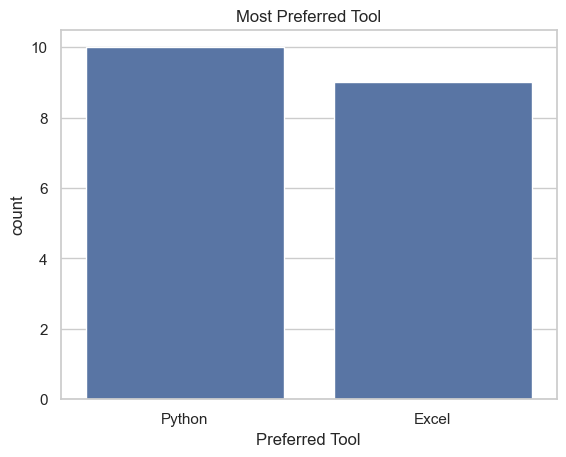

In [8]:
plt.figure()
sns.countplot(x="Preferred Tool", data=df)
plt.title("Most Preferred Tool")
plt.show()

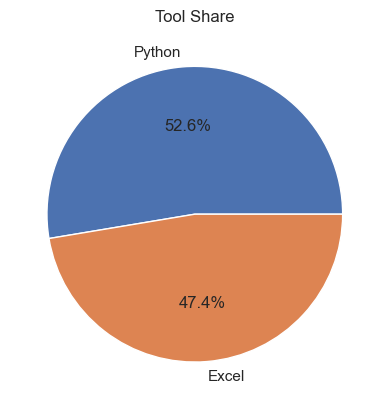

In [9]:
tool_counts.plot.pie(autopct="%1.1f%%")
plt.title("Tool Share")
plt.ylabel("")
plt.show()

In [10]:
avg_satisfaction = df["Satisfaction"].mean()
print("Average Satisfaction:", avg_satisfaction)

Average Satisfaction: 2.9473684210526314


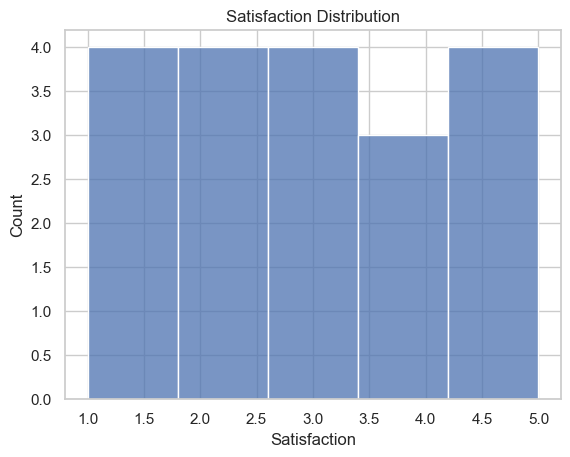

In [11]:
plt.figure()
sns.histplot(df["Satisfaction"], bins=5)
plt.title("Satisfaction Distribution")
plt.show()

In [12]:
age_group_analysis = df.groupby("Age Group")["Satisfaction"].mean()
age_group_analysis

Age Group
18-24    3.000000
25-34    2.888889
Name: Satisfaction, dtype: float64

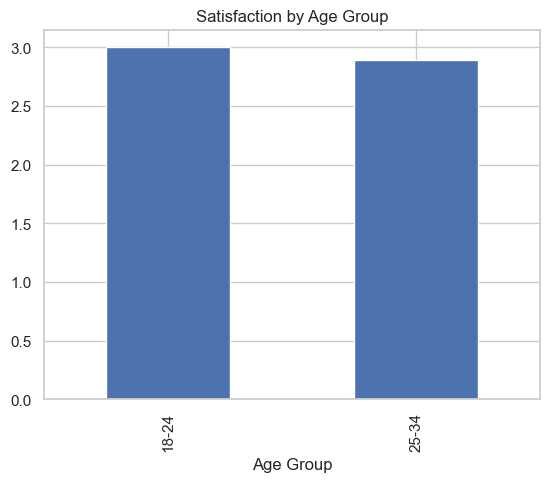

In [13]:
age_group_analysis.plot(kind="bar")
plt.title("Satisfaction by Age Group")
plt.show()